# WR MLP Hybrid - Best of Both Worlds

From the previous MLP comparison we learned:
- Model B (large arch, 40 feat): best R2=0.3289, best RMSE=25.23, but high overfit gap
- Model C (small arch, 40 feat + GaussianNoise/Mixup): best MAE=17.91, lowest overfit, but under-capacity for extremes

This notebook combines both: large capacity + GaussianNoise + Mixup regularization.

Approach:
1. Model D (Fixed Hybrid): Model B's exact architecture [448→128→320→448→256] + GaussianNoise + Mixup at sensible defaults. Isolates the pure effect of adding regularization to a known-good architecture.
2. Model E (Optuna Hybrid): Optuna search over architecture (3-5 layers, 128-448 units) + noise/mixup/weight params. Forced GaussianNoise + LayerNorm + Mixup. Finds the optimal capacity-vs-regularization balance.
3. Final comparison with all previous models (A, B, C) from `WR_MLP_Comparison.ipynb`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, gc, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, GaussianNoise
)

import optuna
from optuna_integration.tfkeras import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


---
## 1. Data Pipeline & Feature Preparation

In [5]:
df = pd.read_csv('../../../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

work_df = df.copy()

wp_rename_map = {
    'yards_wp_<25': 'yards_wp_less_than_25',
    'yards_wp_>75': 'yards_wp_greater_than_75',
    'receptions_wp_<25': 'receptions_wp_less_than_25',
    'receptions_wp_>75': 'receptions_wp_greater_than_75',
    'targets_wp_<25': 'targets_wp_less_than_25',
    'targets_wp_>75': 'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan
    )
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna() & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)
prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (
    prev_season.notna() & (work_df['season'] != prev_season)
).astype(int)
work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1'] = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])
work_df = work_df.drop(columns=available_roll_cols)

momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col, roll5_col = f'{col}_lag1', f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

interaction_cols = []
if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = work_df['target_share_lag1'] * work_df['pregame_total']
    interaction_cols.append('target_volume_interaction')
if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    interaction_cols.append('air_yards_expected')
if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = work_df['catch_rate_lag1'] * work_df['targets_lag1']
    interaction_cols.append('expected_receptions')
if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]
all_feature_columns = pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols

target_col = 'receiving_yards'
id_cols = ['receiver_player_id', 'receiver_player_name', 'game_id', 'season', 'week']
model_df = work_df[id_cols + [target_col] + all_feature_columns].copy()
lag1_cols = [c for c in all_feature_columns if c.endswith('_lag1')]
model_df = model_df.loc[~model_df[lag1_cols].isna().all(axis=1)].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

print(f'Dataset: {model_df.shape}, Total features: {len(all_feature_columns)}')

Dataset: (44396, 189), Total features: 184


In [7]:
# --- Split + selected features + sample weights ---
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df[model_df['season'].isin(train_seasons)].copy()
val_df = model_df[model_df['season'].isin(val_seasons)].copy()
test_df = model_df[model_df['season'].isin(test_seasons)].copy()

y_train_sqrt = train_df['receiving_yards_sqrt'].values
y_val_sqrt = val_df['receiving_yards_sqrt'].values
y_test_sqrt = test_df['receiving_yards_sqrt'].values
y_train_orig = train_df['receiving_yards'].values
y_val_orig = val_df['receiving_yards'].values
y_test_orig = test_df['receiving_yards'].values

# Load top 40 features
with open('../../../results/selected_features_top40.json', 'r') as f:
    selected_features = json.load(f)['selected_features']

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[selected_features].values)
X_val = scaler.transform(val_df[selected_features].values)
X_test = scaler.transform(test_df[selected_features].values)

# Parameterized sample weights: w = 1.0 + strength * sqrt(y/mean)
# strength=1.0 -> original [1.0, 4.12], strength=0.3 -> soft [1.0, ~1.94]
mean_y_train = np.mean(np.clip(y_train_orig, 0, None))
sw_base = np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)  # [0, ~3.12]

def make_weights(strength):
    return 1.0 + strength * sw_base

print(f'Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}')
print(f'Features: {X_train.shape[1]}')
print(f'Sample weights at strength=1.0: [{make_weights(1.0).min():.2f}, {make_weights(1.0).max():.2f}]')
print(f'Sample weights at strength=0.3: [{make_weights(0.3).min():.2f}, {make_weights(0.3).max():.2f}]')

Train: 29276  |  Val: 8921  |  Test: 6199
Features: 40
Sample weights at strength=1.0: [1.00, 4.12]
Sample weights at strength=0.3: [1.00, 1.94]


In [8]:
def evaluate_model(y_true_orig, y_pred_sqrt):
    y_pred_orig = np.clip(y_pred_sqrt, 0, None) ** 2
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, rmse, r2, y_pred_orig


class MixupGenerator(keras.utils.Sequence):
    def __init__(self, X, y, sample_weights, batch_size, alpha=0.2, shuffle=True):
        self.X = X
        self.y = y
        self.sample_weights = sample_weights
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        w_batch = self.sample_weights[batch_idx].copy()

        lam = np.random.beta(self.alpha, self.alpha, size=(len(batch_idx), 1))
        lam_y = lam.flatten()
        shuffle_idx = np.random.permutation(len(batch_idx))

        X_batch = lam * X_batch + (1 - lam) * X_batch[shuffle_idx]
        y_batch = lam_y * y_batch + (1 - lam_y) * y_batch[shuffle_idx]
        w_batch = lam_y * w_batch + (1 - lam_y) * w_batch[shuffle_idx]

        return X_batch.astype(np.float32), y_batch.astype(np.float32), w_batch.astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


def get_final_metrics(hist):
    best_epoch = np.argmin(hist.history['val_loss'])
    return {
        'Best Epoch': best_epoch + 1,
        'Train Loss': hist.history['loss'][best_epoch],
        'Val Loss': hist.history['val_loss'][best_epoch],
        'Loss Gap': hist.history['val_loss'][best_epoch] - hist.history['loss'][best_epoch],
        'Train MAE (sqrt)': hist.history['mae'][best_epoch],
        'Val MAE (sqrt)': hist.history['val_mae'][best_epoch],
        'MAE Gap (sqrt)': hist.history['val_mae'][best_epoch] - hist.history['mae'][best_epoch],
    }

print('Helpers ready.')

Helpers ready.


---
## 2. Model D - Fixed Hybrid (Model B arch + GaussianNoise + Mixup)

Exact same architecture as Model B [448→128→320→448→256], 5 layers, LayerNorm, dropout=0.5.

Added: GaussianNoise(0.15) on input, Mixup(alpha=0.2), original sample weights.

This isolates the effect of adding regularization to the known-good large architecture.

In [5]:
MODEL_B_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_fixed_hybrid(input_dim, params, noise_stddev=0.15):
    """Model B architecture + GaussianNoise on input."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))

    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))

    model.add(Dense(1))

    opt = optimizers.AdamW(learning_rate=params['lr'], weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=losses.Huber(delta=params['huber_delta']), metrics=['mae'])
    return model

In [6]:
print('=== Model D: Fixed Hybrid (Model B arch + GaussianNoise + Mixup) ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model_d = build_fixed_hybrid(X_train.shape[1], MODEL_B_PARAMS, noise_stddev=0.15)
model_d.summary()

sw_d = make_weights(1.0)  # original strength
train_gen_d = MixupGenerator(X_train, y_train_sqrt, sw_d,
                              batch_size=MODEL_B_PARAMS['batch_size'], alpha=0.2)

cb_d = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_d = model_d.fit(
    train_gen_d,
    validation_data=(X_val, y_val_sqrt),
    epochs=500, callbacks=cb_d, verbose=1
)

mae_d, rmse_d, r2_d, pred_d = evaluate_model(y_test_orig, model_d.predict(X_test, verbose=0).flatten())
print(f'\nModel D (Fixed Hybrid) | MAE={mae_d:.2f}  RMSE={rmse_d:.2f}  R2={r2_d:.4f}')

=== Model D: Fixed Hybrid (Model B arch + GaussianNoise + Mixup) ===



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 448)            │        18,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 320)            │        41,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 320)            │           640 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 448)            │       143,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       114,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,329 (1.45 MB)

 Trainable params: 379,329 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.6050 - mae: 2.0348 - val_loss: 0.8929 - val_mae: 2.0224 - learning_rate: 0.0037
Epoch 2/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5206 - mae: 1.9550 - val_loss: 0.9032 - val_mae: 2.0432 - learning_rate: 0.0037
Epoch 3/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.4895 - mae: 1.9283 - val_loss: 0.8674 - val_mae: 1.9707 - learning_rate: 0.0037
Epoch 4/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.4842 - mae: 1.9192 - val_loss: 0.8823 - val_mae: 2.0015 - learning_rate: 0.0037
Epoch 5/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.4814 - mae: 1.9119 - val_loss: 0.8815 - val_mae: 1.9998 - learning_rate: 0.0037
Epoch 6/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.4771 - mae: 1.9137 - val_loss: 0.9020 - val_mae: 2.0412 - learning_rate: 0.0037
Epoch 7/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.4671 - mae: 1.9023 - val_loss: 0.8632 - val_mae: 1.9635 - learning_rate: 0.0037

---
## 3. Model E - Optuna Hybrid (architecture + regularization search)

Forced: GaussianNoise, LayerNorm, Mixup (always on).

Searched:
- Architecture: 3-5 layers, 128-448 units (large enough capacity)
- GaussianNoise stddev: 0.05-0.25
- Mixup alpha: 0.1-0.4
- Sample weight strength: 0.3-1.0 (smooth range between soft and original)
- Dropout: 0.2-0.5
- LR, weight decay, Huber delta, batch size

In [7]:
def create_hybrid_mlp(trial, input_dim):
    """Build hybrid MLP: medium-large capacity + forced regularization."""
    n_layers = trial.suggest_int('n_layers', 3, 5)
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.5, step=0.05)
    noise_stddev = trial.suggest_float('noise_stddev', 0.05, 0.25, step=0.05)
    huber_delta = trial.suggest_float('huber_delta', 0.5, 3.0, step=0.5)
    lr = trial.suggest_float('lr', 5e-5, 5e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-5, 5e-3, log=True)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))

    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 128, 448, step=64)
        model.add(Dense(units, activation='relu'))
        model.add(LayerNormalization())
        dr = dropout_rate * (0.5 if i >= n_layers - 1 else 1.0)
        model.add(Dropout(dr))

    model.add(Dense(1))

    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model


def objective_hybrid(trial):
    tf.keras.backend.clear_session()

    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    mixup_alpha = trial.suggest_float('mixup_alpha', 0.1, 0.4, step=0.05)
    sw_strength = trial.suggest_float('sw_strength', 0.3, 1.0, step=0.1)

    model = create_hybrid_mlp(trial, X_train.shape[1])
    sw = make_weights(sw_strength)

    train_gen = MixupGenerator(X_train, y_train_sqrt, sw,
                                batch_size=batch_size, alpha=mixup_alpha)

    cb = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=15, restore_best_weights=True, min_delta=1e-4
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=7, min_lr=1e-6
        ),
        TFKerasPruningCallback(trial, 'val_loss'),
    ]

    model.fit(
        train_gen,
        validation_data=(X_val, y_val_sqrt),
        epochs=200, callbacks=cb, verbose=0
    )

    val_pred_sqrt = model.predict(X_val, verbose=0).flatten()
    val_pred_orig = np.clip(val_pred_sqrt, 0, None) ** 2
    return np.sqrt(mean_squared_error(y_val_orig, val_pred_orig))

print('Hybrid objective defined.')

Hybrid objective defined.


In [8]:
hybrid_study = optuna.create_study(
    direction='minimize',
    study_name='mlp_hybrid',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

print('Starting Hybrid MLP Optuna optimization (100 trials)...')
print('Search: 3-5 layers, 128-448 units, forced GaussianNoise + LayerNorm + Mixup')
print('Also searching: sample weight strength, noise stddev, mixup alpha\n')

hybrid_study.optimize(objective_hybrid, n_trials=100, show_progress_bar=True)

print(f'\nBest Hybrid trial:')
print(f'  Val RMSE: {hybrid_study.best_value:.4f}')
print(f'  Params: {json.dumps(hybrid_study.best_params, indent=2)}')

Starting Hybrid MLP Optuna optimization (100 trials)...
Search: 3-5 layers, 128-448 units, forced GaussianNoise + LayerNorm + Mixup
Also searching: sample weight strength, noise stddev, mixup alpha



Best trial: 64. Best value: 25.6239: 100%|██████████| 100/100 [1:33:40<00:00, 56.20s/it]


Best Hybrid trial:
  Val RMSE: 25.6239
  Params: {
  "batch_size": 32,
  "mixup_alpha": 0.2,
  "sw_strength": 0.9000000000000001,
  "n_layers": 4,
  "dropout": 0.4,
  "noise_stddev": 0.25,
  "huber_delta": 0.5,
  "lr": 0.0002448790084311133,
  "weight_decay": 0.00020741384776951126,
  "units_0": 320,
  "units_1": 384,
  "units_2": 192,
  "units_3": 128
}


In [9]:
print('=== Model E: Training best Hybrid MLP ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

bp = hybrid_study.best_params
best_trial = hybrid_study.best_trial

model_e = create_hybrid_mlp(best_trial, X_train.shape[1])
model_e.summary()

sw_e = make_weights(bp['sw_strength'])
train_gen_e = MixupGenerator(X_train, y_train_sqrt, sw_e,
                              batch_size=bp['batch_size'], alpha=bp['mixup_alpha'])

cb_e = [
    callbacks.ModelCheckpoint('mlp_hybrid_best.keras', monitor='val_loss',
                              save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_e = model_e.fit(
    train_gen_e,
    validation_data=(X_val, y_val_sqrt),
    epochs=500, callbacks=cb_e, verbose=1
)

mae_e, rmse_e, r2_e, pred_e = evaluate_model(y_test_orig, model_e.predict(X_test, verbose=0).flatten())
print(f'\nModel E (Optuna Hybrid) | MAE={mae_e:.2f}  RMSE={rmse_e:.2f}  R2={r2_e:.4f}')

=== Model E: Training best Hybrid MLP ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 320)            │        13,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 320)            │           640 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 384)            │       123,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 384)            │           768 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 192)            │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,185 (926.50 KB)

 Trainable params: 237,185 (926.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7011 - mae: 2.1876 - val_loss: 0.9929 - val_mae: 2.2235 - learning_rate: 2.4488e-04
Epoch 2/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4743 - mae: 1.9719 - val_loss: 0.9291 - val_mae: 2.0955 - learning_rate: 2.4488e-04
Epoch 3/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4392 - mae: 1.9343 - val_loss: 0.9269 - val_mae: 2.0910 - learning_rate: 2.4488e-04
Epoch 4/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4341 - mae: 1.9300 - val_loss: 0.8939 - val_mae: 2.0246 - learning_rate: 2.4488e-04
Epoch 5/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4209 - mae: 1.9184 - val_loss: 0.9030 - val_mae: 2.0430 - learning_rate: 2.4488e-04
Epoch 6/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4256 - mae: 1.9194 - val_loss: 0.8910 - val_mae: 2.0188 - learning_rate: 2.4488e-04
Epoch 7/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.4188 - mae: 1.9127 - val_loss: 0.8829 - val_mae: 2.0020

---
## 4. Optuna Diagnostics

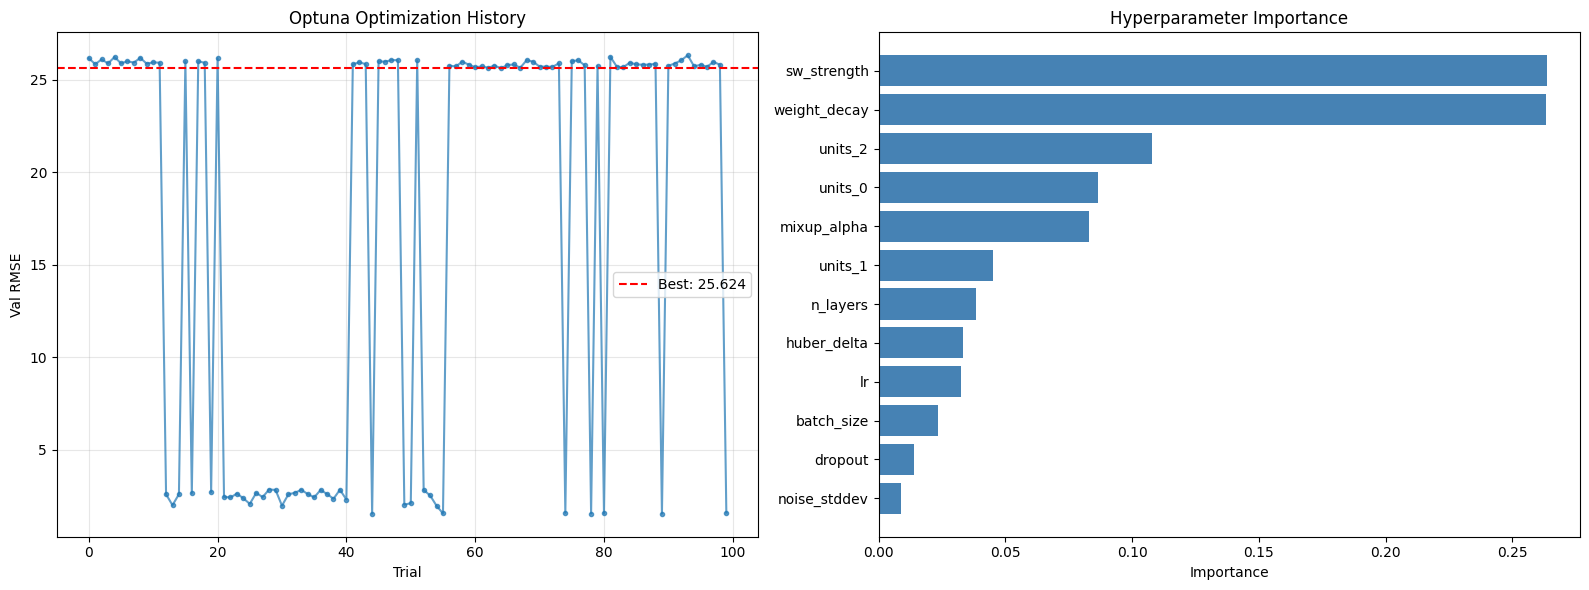

In [10]:
from optuna.importance import get_param_importances

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Optimization history
ax = axes[0]
trial_vals = [t.value for t in hybrid_study.trials if t.value is not None]
ax.plot(trial_vals, 'o-', markersize=3, alpha=0.7)
ax.axhline(y=hybrid_study.best_value, color='r', linestyle='--',
           label=f'Best: {hybrid_study.best_value:.3f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Val RMSE')
ax.set_title('Optuna Optimization History')
ax.legend()
ax.grid(True, alpha=0.3)

# Hyperparameter importance
ax = axes[1]
try:
    importances = get_param_importances(hybrid_study)
    top_k = dict(list(importances.items())[:12])
    ax.barh(list(top_k.keys())[::-1], list(top_k.values())[::-1], color='steelblue')
    ax.set_title('Hyperparameter Importance')
    ax.set_xlabel('Importance')
except Exception as e:
    ax.text(0.5, 0.5, f'Could not compute: {e}',
            transform=ax.transAxes, ha='center', va='center')

plt.tight_layout()
plt.savefig('../results/mlp_hybrid_optuna_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Learning Curves - Model D vs Model E

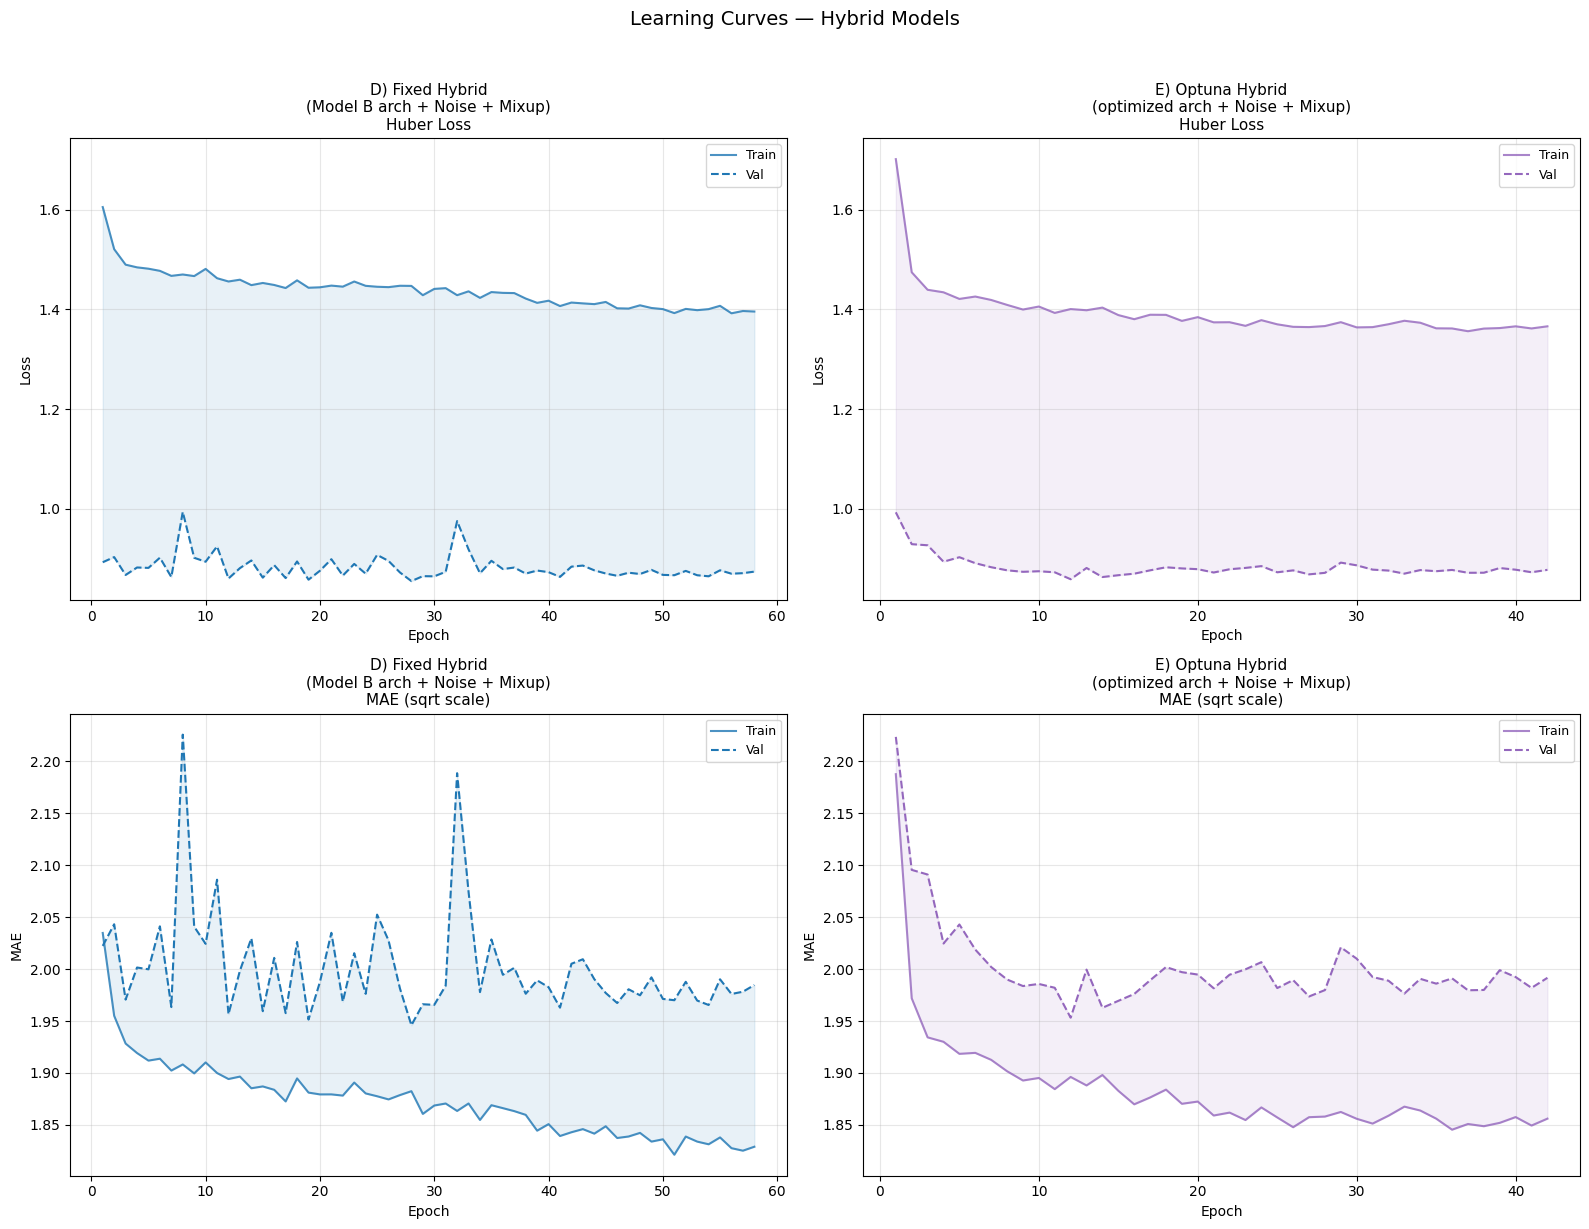

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col, (hist, title, color) in enumerate([
    (history_d, 'D) Fixed Hybrid\n(Model B arch + Noise + Mixup)', '#1f77b4'),
    (history_e, 'E) Optuna Hybrid\n(optimized arch + Noise + Mixup)', '#9467bd'),
]):
    epochs = range(1, len(hist.history['loss']) + 1)

    # Loss
    ax = axes[0, col]
    ax.plot(epochs, hist.history['loss'], label='Train', color=color, alpha=0.8)
    ax.plot(epochs, hist.history['val_loss'], label='Val', color=color, linestyle='--')
    ax.fill_between(epochs, hist.history['loss'], hist.history['val_loss'],
                    alpha=0.1, color=color)
    gap = hist.history['val_loss'][-1] - hist.history['loss'][-1]
    ax.set_title(f'{title}\nHuber Loss', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # MAE
    ax = axes[1, col]
    ax.plot(epochs, hist.history['mae'], label='Train', color=color, alpha=0.8)
    ax.plot(epochs, hist.history['val_mae'], label='Val', color=color, linestyle='--')
    ax.fill_between(epochs, hist.history['mae'], hist.history['val_mae'],
                    alpha=0.1, color=color)
    ax.set_title(f'{title}\nMAE (sqrt scale)', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Equalize y-axes
for row in range(2):
    ymin = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
    ymax = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
    axes[row, 0].set_ylim(ymin, ymax)
    axes[row, 1].set_ylim(ymin, ymax)

plt.suptitle('Learning Curves — Hybrid Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/mlp_hybrid_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Full Comparison - All 5 Models (A, B, C, D, E)

In [12]:
# Load previous results
prev_results = pd.read_csv('../results/mlp_comparison_results.csv', index_col=0)

# Build new results
new_results = {}

r = get_final_metrics(history_d)
r.update({'Test MAE': mae_d, 'Test RMSE': rmse_d, 'Test R2': r2_d, 'Features': 40})
new_results['D) Fixed Hybrid (40 feat)'] = r

r = get_final_metrics(history_e)
r.update({'Test MAE': mae_e, 'Test RMSE': rmse_e, 'Test R2': r2_e, 'Features': 40})
new_results['E) Optuna Hybrid (40 feat)'] = r

new_df = pd.DataFrame(new_results).T
new_df.index.name = 'Model'

# Combine all
all_results = pd.concat([prev_results, new_df])

print('\n' + '=' * 110)
print('FULL MLP COMPARISON — All 5 Models')
print('=' * 110)
print(all_results[['Features', 'Best Epoch', 'Test MAE', 'Test RMSE', 'Test R2',
                    'Loss Gap', 'MAE Gap (sqrt)']].round(4).to_string())
print('=' * 110)

# Rank
print('\n--- Rankings ---')
for metric, ascending in [('Test MAE', True), ('Test RMSE', True), ('Test R2', False)]:
    ranked = all_results.sort_values(metric, ascending=ascending)
    best_name = ranked.index[0]
    best_val = ranked[metric].iloc[0]
    print(f'  Best {metric}: {best_name} ({best_val:.4f})')


FULL MLP COMPARISON — All 5 Models
                            Features  Best Epoch  Test MAE  Test RMSE  Test R2  Loss Gap  MAE Gap (sqrt)
Model                                                                                                   
A) Original MLP (184 feat)     184.0        19.0   18.1029    25.6247   0.3079   -0.6236          0.0177
B) Same arch (40 feat)          40.0        27.0   18.1950    25.2329   0.3289   -0.6402          0.0037
C) Improved MLP (40 feat)       40.0        22.0   17.9103    25.4919   0.3151   -0.1099          0.1621
D) Fixed Hybrid (40 feat)       40.0        28.0   17.8289    25.6690   0.3055   -0.5919          0.0635
E) Optuna Hybrid (40 feat)      40.0        12.0   17.8833    25.3525   0.3225   -0.5417          0.0571

--- Rankings ---
  Best Test MAE: D) Fixed Hybrid (40 feat) (17.8289)
  Best Test RMSE: B) Same arch (40 feat) (25.2329)
  Best Test R2: B) Same arch (40 feat) (0.3289)


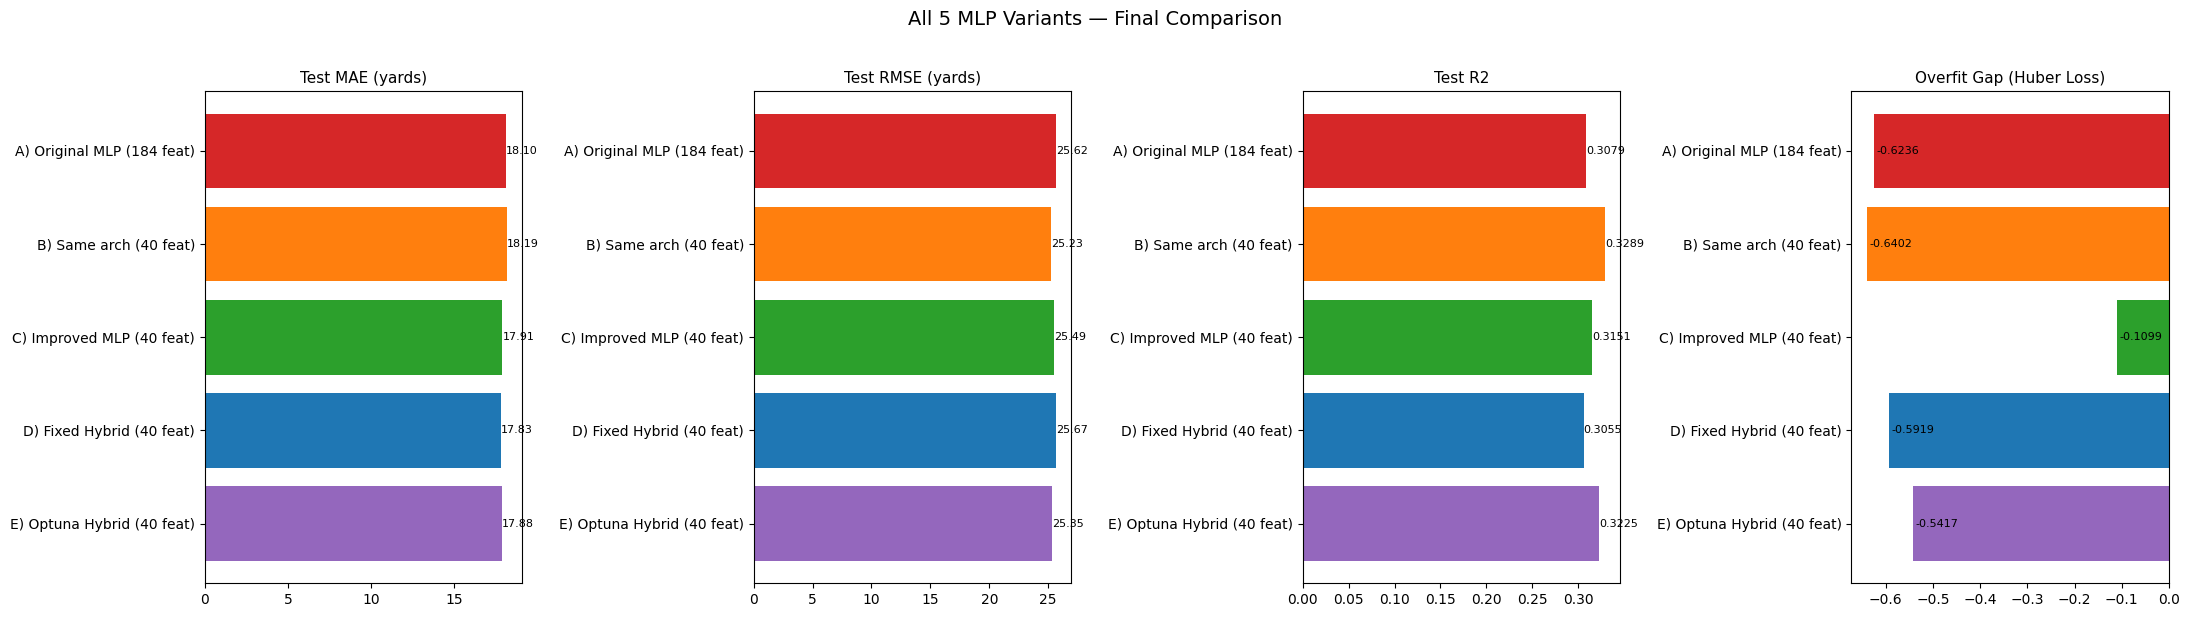

In [13]:
# --- Summary bar chart for all 5 models ---
plot_df = all_results[['Test MAE', 'Test RMSE', 'Test R2', 'Loss Gap']].copy()

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

for idx, (metric, title) in enumerate([
    ('Test MAE', 'Test MAE (yards)'),
    ('Test RMSE', 'Test RMSE (yards)'),
    ('Test R2', 'Test R2'),
    ('Loss Gap', 'Overfit Gap (Huber Loss)'),
]):
    ax = axes[idx]
    vals = plot_df[metric].values
    bars = ax.barh(plot_df.index, vals, color=colors[:len(plot_df)])
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        fmt = '.2f' if 'MAE' in metric or 'RMSE' in metric else '.4f'
        offset = 0.01 * abs(max(vals) - min(vals)) if max(vals) != min(vals) else 0.01
        ax.text(v + offset, i, f'{v:{fmt}}', va='center', fontsize=8)

plt.suptitle('All 5 MLP Variants — Final Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/mlp_hybrid_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# --- Detailed analysis print ---
print('\n=== DETAILED ANALYSIS ===')
print()

# Reference values
b_mae = prev_results.loc['B) Same arch (40 feat)', 'Test MAE']
b_rmse = prev_results.loc['B) Same arch (40 feat)', 'Test RMSE']
b_r2 = prev_results.loc['B) Same arch (40 feat)', 'Test R2']
c_mae = prev_results.loc['C) Improved MLP (40 feat)', 'Test MAE']
c_rmse = prev_results.loc['C) Improved MLP (40 feat)', 'Test RMSE']
c_r2 = prev_results.loc['C) Improved MLP (40 feat)', 'Test R2']

print(f'Model D (Fixed Hybrid) vs Model B (baseline large arch):')
print(f'  MAE:  {b_mae:.2f} -> {mae_d:.2f} ({"+" if mae_d > b_mae else ""}{mae_d - b_mae:.2f})')
print(f'  RMSE: {b_rmse:.2f} -> {rmse_d:.2f} ({"+" if rmse_d > b_rmse else ""}{rmse_d - b_rmse:.2f})')
print(f'  R2:   {b_r2:.4f} -> {r2_d:.4f} ({"+" if r2_d > b_r2 else ""}{r2_d - b_r2:.4f})')
print()

print(f'Model E (Optuna Hybrid) vs Model B (baseline large arch):')
print(f'  MAE:  {b_mae:.2f} -> {mae_e:.2f} ({"+" if mae_e > b_mae else ""}{mae_e - b_mae:.2f})')
print(f'  RMSE: {b_rmse:.2f} -> {rmse_e:.2f} ({"+" if rmse_e > b_rmse else ""}{rmse_e - b_rmse:.2f})')
print(f'  R2:   {b_r2:.4f} -> {r2_e:.4f} ({"+" if r2_e > b_r2 else ""}{r2_e - b_r2:.4f})')
print()

print(f'Model E (Optuna Hybrid) vs Model C (small regularized):')
print(f'  MAE:  {c_mae:.2f} -> {mae_e:.2f} ({"+" if mae_e > c_mae else ""}{mae_e - c_mae:.2f})')
print(f'  RMSE: {c_rmse:.2f} -> {rmse_e:.2f} ({"+" if rmse_e > c_rmse else ""}{rmse_e - c_rmse:.2f})')
print(f'  R2:   {c_r2:.4f} -> {r2_e:.4f} ({"+" if r2_e > c_r2 else ""}{r2_e - c_r2:.4f})')
print()

# Best overall
best_mae_model = all_results['Test MAE'].idxmin()
best_rmse_model = all_results['Test RMSE'].idxmin()
best_r2_model = all_results['Test R2'].idxmax()
print(f'Overall best MAE:  {best_mae_model} ({all_results.loc[best_mae_model, "Test MAE"]:.4f})')
print(f'Overall best RMSE: {best_rmse_model} ({all_results.loc[best_rmse_model, "Test RMSE"]:.4f})')
print(f'Overall best R2:   {best_r2_model} ({all_results.loc[best_r2_model, "Test R2"]:.4f})')


=== DETAILED ANALYSIS ===

Model D (Fixed Hybrid) vs Model B (baseline large arch):
  MAE:  18.19 -> 17.83 (-0.37)
  RMSE: 25.23 -> 25.67 (+0.44)
  R2:   0.3289 -> 0.3055 (-0.0234)

Model E (Optuna Hybrid) vs Model B (baseline large arch):
  MAE:  18.19 -> 17.88 (-0.31)
  RMSE: 25.23 -> 25.35 (+0.12)
  R2:   0.3289 -> 0.3225 (-0.0064)

Model E (Optuna Hybrid) vs Model C (small regularized):
  MAE:  17.91 -> 17.88 (-0.03)
  RMSE: 25.49 -> 25.35 (-0.14)
  R2:   0.3151 -> 0.3225 (+0.0075)

Overall best MAE:  D) Fixed Hybrid (40 feat) (17.8289)
Overall best RMSE: B) Same arch (40 feat) (25.2329)
Overall best R2:   B) Same arch (40 feat) (0.3289)


In [15]:
# Save everything
output = {
    'model_d': {
        'name': 'Fixed Hybrid (Model B arch + GaussianNoise + Mixup)',
        'architecture': MODEL_B_PARAMS,
        'noise_stddev': 0.15,
        'mixup_alpha': 0.2,
        'sw_strength': 1.0,
        'test_mae': round(mae_d, 4),
        'test_rmse': round(rmse_d, 4),
        'test_r2': round(r2_d, 4),
    },
    'model_e': {
        'name': 'Optuna Hybrid (optimized arch + GaussianNoise + Mixup)',
        'best_params': hybrid_study.best_params,
        'best_val_rmse': hybrid_study.best_value,
        'test_mae': round(mae_e, 4),
        'test_rmse': round(rmse_e, 4),
        'test_r2': round(r2_e, 4),
    },
}

with open('../results/mlp_hybrid_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

all_results.to_csv('../results/mlp_all_5_models_comparison.csv')

print('Saved:')
print('  results/mlp_hybrid_results.json')
print('  results/mlp_all_5_models_comparison.csv')

Saved:
  results/mlp_hybrid_results.json
  results/mlp_all_5_models_comparison.csv
